In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [5]:
df = pd.read_csv("creditcard.csv")
df.shape

(3973, 31)

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    3973 non-null   int64  
 1   V1      3973 non-null   float64
 2   V2      3973 non-null   float64
 3   V3      3973 non-null   float64
 4   V4      3973 non-null   float64
 5   V5      3973 non-null   float64
 6   V6      3973 non-null   float64
 7   V7      3973 non-null   float64
 8   V8      3973 non-null   float64
 9   V9      3973 non-null   float64
 10  V10     3973 non-null   float64
 11  V11     3973 non-null   float64
 12  V12     3973 non-null   float64
 13  V13     3973 non-null   float64
 14  V14     3973 non-null   float64
 15  V15     3973 non-null   float64
 16  V16     3973 non-null   float64
 17  V17     3973 non-null   float64
 18  V18     3973 non-null   float64
 19  V19     3973 non-null   float64
 20  V20     3973 non-null   float64
 21  V21     3973 non-null   float64
 22  

In [9]:
print(df["Class"].value_counts())

Class
0.0    3970
1.0       2
Name: count, dtype: int64


In [10]:
print("Missing values in Class: ",df["Class"].isna().sum())

df = df.dropna(subset=["Class"])

X = df.drop("Class",axis =1)
y = df["Class"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state= 42,stratify=y)

print("Training data: ",X_train.shape)
print("Testing data: ",X_test.shape)

Missing values in Class:  1
Training data:  (3177, 30)
Testing data:  (795, 30)


In [11]:
rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    class_weight="balanced",
    random_state = 42
)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [12]:
y_pred = rf.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  1.0


In [13]:
cm = confusion_matrix(y_test,y_pred)
print("Confusion_matrix:")
print(cm)

Confusion_matrix:
[[795]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [14]:
cr = classification_report(y_test,y_pred)
print("Classification report:")
print(cr)

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       795

    accuracy                           1.00       795
   macro avg       1.00      1.00      1.00       795
weighted avg       1.00      1.00      1.00       795



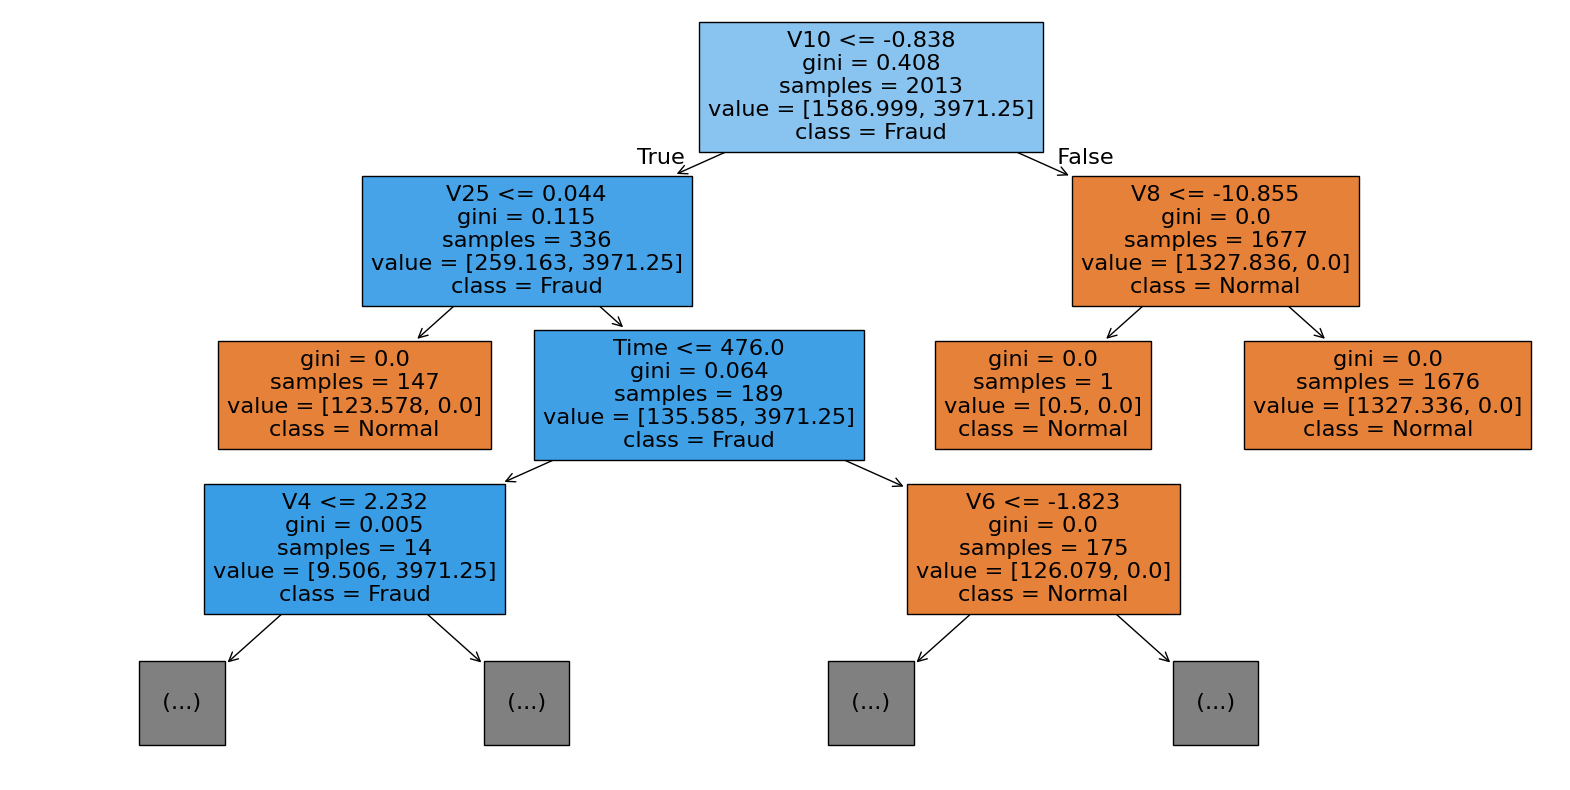

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))

plot_tree(
    rf.estimators_[50],
    max_depth=3,
    feature_names=X.columns,
    class_names=["Normal","Fraud"],
    filled=True
)
plt.show()